<a href="https://colab.research.google.com/github/Annasiby/ML/blob/main/Smoker%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install extra libraries
!pip install -q torchsummary seaborn scikit-learn

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujaykapadnis/smoking")

print("Path to dataset files:", path)

100%|██████████| 63.8M/63.8M [00:00<00:00, 259MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5


In [3]:
import os
import time
import copy
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchsummary import summary
from tqdm.notebook import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files))

/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5 0
/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Testing 0
/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Testing/Testing 224
/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Training 0
/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Training/Training 716
/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Validation 0
/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Validation/Validation 180


In [5]:
import os
import shutil

src = path + "/Training/Training"
dst = path + "/Training_fixed"

os.makedirs(dst + "/smoking", exist_ok=True)
os.makedirs(dst + "/notsmoking", exist_ok=True)

for file in os.listdir(src):
    if "smoking" in file.lower():
        shutil.copy(os.path.join(src, file), dst + "/smoking/" + file)
    else:
        shutil.copy(os.path.join(src, file), dst + "/notsmoking/" + file)

In [6]:
import os
import shutil

src = path + "/Training/Training"
dst = path + "/Training_fixed"

os.makedirs(dst + "/smoking", exist_ok=True)
os.makedirs(dst + "/notsmoking", exist_ok=True)

for file in os.listdir(src):
    fname = file.lower()

    if "notsmoking" in fname:
        shutil.copy(os.path.join(src, file), dst + "/notsmoking/" + file)
    elif "smoking" in fname:
        shutil.copy(os.path.join(src, file), dst + "/smoking/" + file)

In [7]:
for split in ["Training", "Validation", "Testing"]:
    src = path + f"/{split}/{split}"
    dst = path + f"/{split}_fixed"

    os.makedirs(dst + "/smoking", exist_ok=True)
    os.makedirs(dst + "/notsmoking", exist_ok=True)

    for file in os.listdir(src):
        fname = file.lower()

        if "notsmoking" in fname:
            shutil.copy(os.path.join(src, file), dst + "/notsmoking/" + file)
        elif "smoking" in fname:
            shutil.copy(os.path.join(src, file), dst + "/smoking/" + file)

In [8]:
flow_from_directory()

NameError: name 'flow_from_directory' is not defined

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = path + "/Training_fixed"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 1074 images belonging to 2 classes.


In [10]:
val_dir = path + "/Validation_fixed"

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 180 images belonging to 2 classes.


In [11]:
import os
import time
import copy
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchsummary import summary
from tqdm.notebook import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
DATASET_PATH = '/content/drive/MyDrive/smoking_dataset'   # <── change this
OUTPUT_DIR   = '/content/outputs'
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LABEL_LIST = ['notsmoking', 'smoking']
LABEL_TO_ID = {label: idx for idx, label in enumerate(LABEL_LIST)}
print('Classes:', LABEL_TO_ID)

Classes: {'notsmoking': 0, 'smoking': 1}


In [19]:
def build_dataframe(root_path, label_list):
    """
    Supports two layouts:
      A) root/class_name/*.jpg  (subfolder per class)
      B) root/*.jpg             (flat, filenames start with class name)
    """
    records = []

    # Layout A — subfolders
    for label in label_list:
        folder = os.path.join(root_path, label)
        if os.path.isdir(folder):
            for ext in ('*.jpg', '*.jpeg', '*.png'):
                for img_path in glob(os.path.join(folder, ext)):
                    records.append({'path': img_path,
                                    'label': label,
                                    'class_id': LABEL_TO_ID[label]})

    # Layout B — flat folder
    if len(records) == 0:
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            for img_path in glob(os.path.join(root_path, ext)):
                fname = os.path.splitext(os.path.basename(img_path))[0]
                for label in label_list:
                    if fname.lower().startswith(label):
                        records.append({'path': img_path,
                                        'label': label,
                                        'class_id': LABEL_TO_ID[label]})
                        break

    df = pd.DataFrame(records)
    assert len(df) > 0, f'No images found under {root_path}. Check DATASET_PATH.'
    return df.reset_index(drop=True)


full_df = build_dataframe(DATASET_PATH, LABEL_LIST)
print(f'Total images found: {len(full_df)}')
print(full_df['label'].value_counts())
full_df.head()

AssertionError: No images found under /content/drive/MyDrive/smoking_dataset. Check DATASET_PATH.

In [17]:
import os

print(os.path.exists("/content/drive/MyDrive/smoking_dataset"))

False


In [18]:
import os
os.listdir("/content/drive/MyDrive")

['Colab Notebooks']

In [22]:
# ─────────────────────────────────────────────────────────────────
# ✏️  UPDATE THIS PATH to point to your dataset folder on Drive
# ─────────────────────────────────────────────────────────────────
DATASET_PATH = '/content/drive/MyDrive/dataset'   # <── change this
OUTPUT_DIR   = '/content/outputs'
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LABEL_LIST = ['notsmoking', 'smoking']
LABEL_TO_ID = {label: idx for idx, label in enumerate(LABEL_LIST)}
print('Classes:', LABEL_TO_ID)

Classes: {'notsmoking': 0, 'smoking': 1}


In [23]:
def build_dataframe(root_path, label_list):
    """
    Supports two layouts:
      A) root/class_name/*.jpg  (subfolder per class)
      B) root/*.jpg             (flat, filenames start with class name)
    """
    records = []

    # Layout A — subfolders
    for label in label_list:
        folder = os.path.join(root_path, label)
        if os.path.isdir(folder):
            for ext in ('*.jpg', '*.jpeg', '*.png'):
                for img_path in glob(os.path.join(folder, ext)):
                    records.append({'path': img_path,
                                    'label': label,
                                    'class_id': LABEL_TO_ID[label]})

    # Layout B — flat folder
    if len(records) == 0:
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            for img_path in glob(os.path.join(root_path, ext)):
                fname = os.path.splitext(os.path.basename(img_path))[0]
                for label in label_list:
                    if fname.lower().startswith(label):
                        records.append({'path': img_path,
                                        'label': label,
                                        'class_id': LABEL_TO_ID[label]})
                        break

    df = pd.DataFrame(records)
    assert len(df) > 0, f'No images found under {root_path}. Check DATASET_PATH.'
    return df.reset_index(drop=True)


full_df = build_dataframe(DATASET_PATH, LABEL_LIST)
print(f'Total images found: {len(full_df)}')
print(full_df['label'].value_counts())
full_df.head()

Total images found: 1120
label
notsmoking    560
smoking       560
Name: count, dtype: int64


,path,label,class_id
0,/content/drive/MyDrive/dataset/notsmoking/nots...,notsmoking,0
1,/content/drive/MyDrive/dataset/notsmoking/nots...,notsmoking,0
2,/content/drive/MyDrive/dataset/notsmoking/nots...,notsmoking,0
3,/content/drive/MyDrive/dataset/notsmoking/nots...,notsmoking,0
4,/content/drive/MyDrive/dataset/notsmoking/nots...,notsmoking,0


Train :   784  (70.0%)
Val   :   168  (15.0%)
Test  :   168  (15.0%)


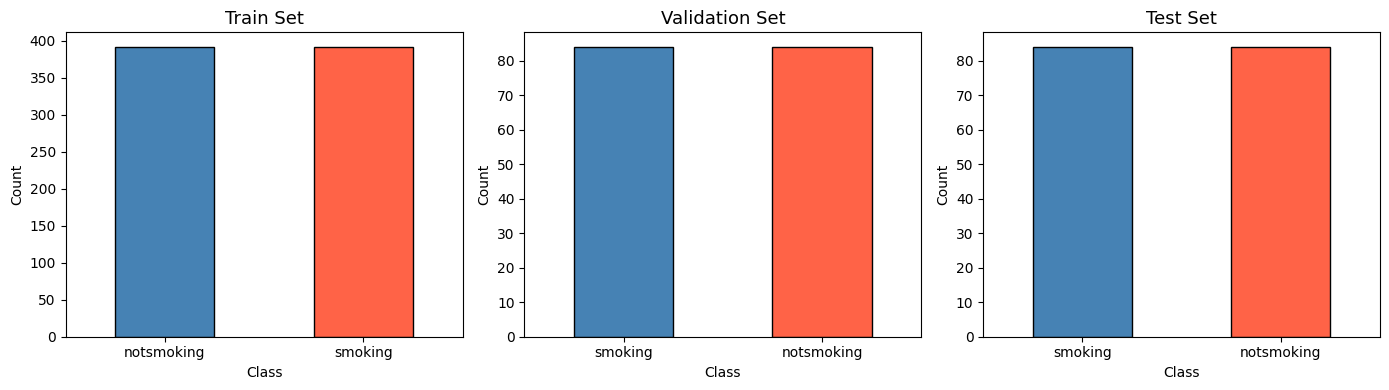

In [24]:
# Stratified split so class balance is preserved in every subset

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.30,
    stratify=full_df['class_id'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,          # 50% of the 30% = 15% each
    stratify=temp_df['class_id'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):>5}  ({len(train_df)/len(full_df)*100:.1f}%)')
print(f'Val   : {len(val_df):>5}  ({len(val_df)/len(full_df)*100:.1f}%)')
print(f'Test  : {len(test_df):>5}  ({len(test_df)/len(full_df)*100:.1f}%)')

# Class distribution check
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df, title in zip(axes,
                          [train_df, val_df, test_df],
                          ['Train', 'Validation', 'Test']):
    df['label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='black')
    ax.set_title(f'{title} Set', fontsize=13)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ImageNet statistics (used to standardize pixel values for ResNet50)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

# ── Training transforms (augmentation + normalization) ──────────────
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=(-10, 10),
                             translate=(0.1, 0.1),
                             scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.05),
    transforms.ToTensor(),                          # [0,255] → [0.0,1.0]
    transforms.Normalize(mean=IMAGENET_MEAN,        # standardize RGB
                         std=IMAGENET_STD),
])

# ── Validation / Test transforms (no augmentation) ──────────────────
eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,
                         std=IMAGENET_STD),
])

print('Transforms defined.')
print(f'  Input  : RGB PIL image')
print(f'  Resize : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Normalize mean: {IMAGENET_MEAN}')
print(f'  Normalize std : {IMAGENET_STD}')

Transforms defined.
  Input  : RGB PIL image
  Resize : 224x224
  Normalize mean: [0.485, 0.456, 0.406]
  Normalize std : [0.229, 0.224, 0.225]


In [26]:
class SmokerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')   # ensure 3-channel RGB
        label = int(row['class_id'])
        if self.transform:
            image = self.transform(image)
        return image, label


# ── DataLoaders ─────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_dataset = SmokerDataset(train_df, transform=train_transforms)
val_dataset   = SmokerDataset(val_df,   transform=eval_transforms)
test_dataset  = SmokerDataset(test_df,  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 25
Val   batches : 6
Test  batches : 6


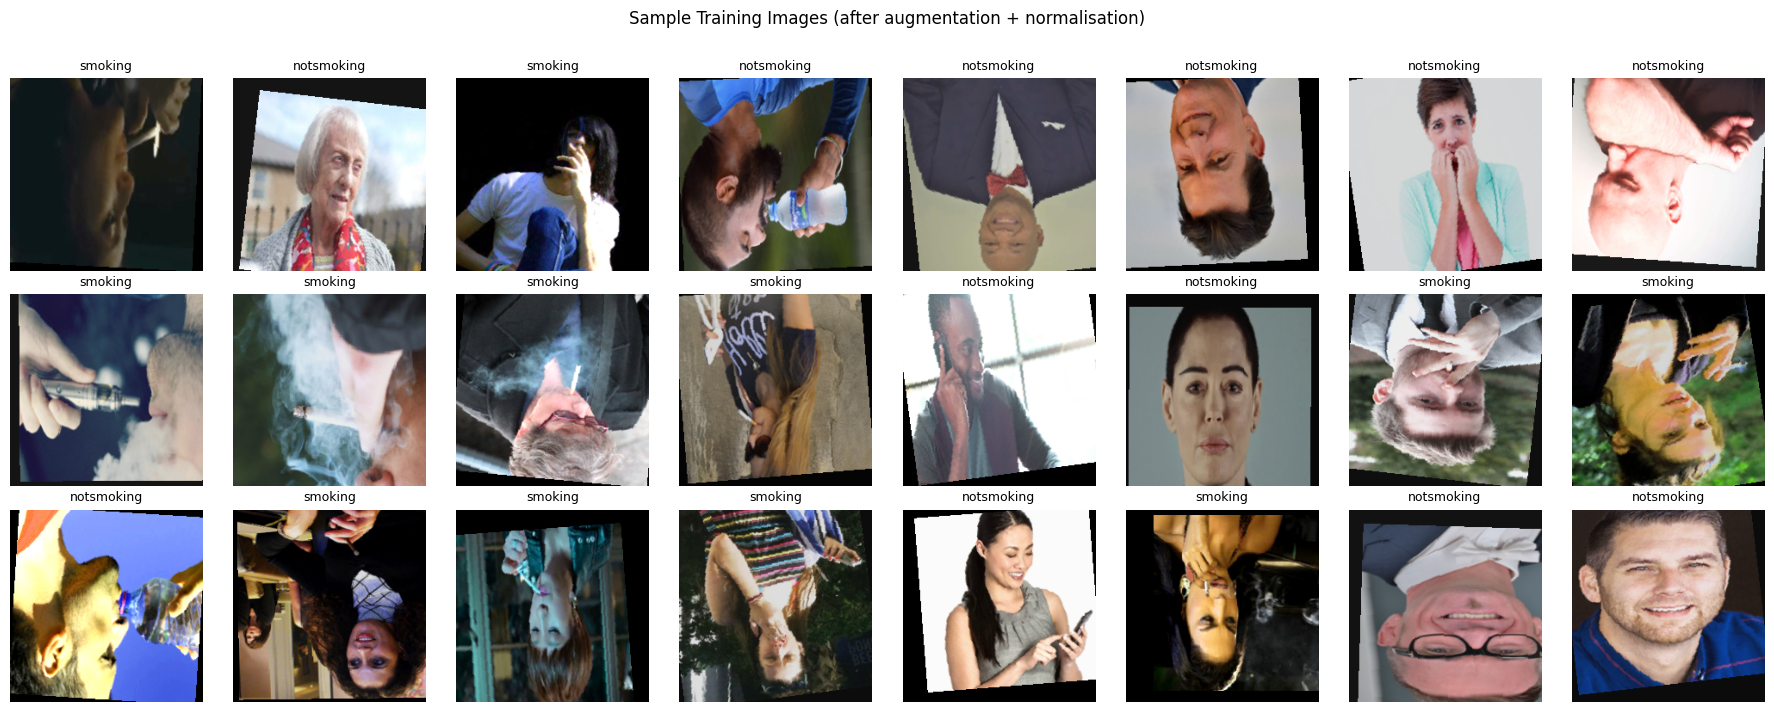

In [27]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


images, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= len(images): break
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(LABEL_LIST[labels[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images (after augmentation + normalisation)', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
NUM_CLASSES = len(LABEL_LIST)

def build_resnet50(num_classes, freeze_backbone=True):
    """
    Loads ImageNet-pretrained ResNet50.
    - Freezes all backbone layers.
    - Replaces the final FC layer with:
        Linear → BatchNorm → ReLU → Dropout → Linear(num_classes)
    - Only the new head is trained (fine-tuning).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final classification head
    in_features = model.fc.in_features   # 2048 for ResNet50
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),              # Batch Normalization
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(512, num_classes)       # logits → passed to CrossEntropyLoss
        # Note: CrossEntropyLoss applies Softmax internally
    )

    return model


model = build_resnet50(NUM_CLASSES, freeze_backbone=True)
model = model.to(device)

# Count trainable vs frozen parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}  ({trainable_params/total_params*100:.2f}%)')

print('\n── Final FC head (fine-tuned layers) ──')
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Total parameters    : 24,559,170
Trainable parameters: 1,051,138  (4.28%)

── Final FC head (fine-tuned layers) ──
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=2, bias=True)
)


In [29]:
# Model summary (only the trainable head)
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [30]:
EPOCHS        = 50
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
T0            = 10    # CosineAnnealingWarmRestarts period
T_MULT        = 2     # doubles period after each restart

# ── Loss ─────────────────────────────────────────────────────────────
# CrossEntropyLoss = log_softmax + NLLLoss  →  Softmax is applied internally
criterion = nn.CrossEntropyLoss()

# ── Optimiser (only update the new head parameters) ──────────────────
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# ── Scheduler: Cosine Annealing with Warm Restarts ───────────────────
# LR decays from LR → 0 over T0 epochs, then restarts — great for avoiding plateaus
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T0, T_mult=T_MULT, eta_min=1e-6
)

print('Setup complete.')
print(f'  Loss      : CrossEntropyLoss (Softmax applied internally)')
print(f'  Optimiser : AdamW   lr={LR}, weight_decay={WEIGHT_DECAY}')
print(f'  Scheduler : CosineAnnealingWarmRestarts  T0={T0}, T_mult={T_MULT}')
print(f'  Epochs    : {EPOCHS}')

Setup complete.
  Loss      : CrossEntropyLoss (Softmax applied internally)
  Optimiser : AdamW   lr=0.001, weight_decay=0.0001
  Scheduler : CosineAnnealingWarmRestarts  T0=10, T_mult=2
  Epochs    : 50


In [31]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)           # logits (Softmax NOT applied yet)
        loss    = criterion(outputs, labels)  # CrossEntropy applies Softmax here
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * images.size(0)
        _, predicted     = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total           += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss    += loss.item() * images.size(0)
            _, predicted     = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total           += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc


print('Train / eval functions ready.')

Train / eval functions ready.


In [32]:
# ── Training logs ────────────────────────────────────────────────────
logs = {'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [],
        'lr':         []}

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8} | {"LR":>10}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    # Step the cosine scheduler after each epoch
    scheduler.step(epoch - 1)   # CosineAnnealingWarmRestarts expects epoch index
    current_lr = optimizer.param_groups[0]['lr']

    # Log
    logs['train_loss'].append(train_loss)
    logs['train_acc'].append(train_acc)
    logs['val_loss'].append(val_loss)
    logs['val_acc'].append(val_acc)
    logs['lr'].append(current_lr)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'{CHECKPOINT_DIR}/best_resnet50.pth')
        marker = '  ◀ best'
    else:
        marker = ''

    elapsed = time.time() - t0
    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | '
          f'{val_loss:>8.4f} | {val_acc*100:>7.2f}% | {current_lr:>10.2e}{marker}')


print(f'\nTraining complete.  Best Val Acc: {best_val_acc*100:.2f}%')
print(f'Best weights saved to: {CHECKPOINT_DIR}/best_resnet50.pth')

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |         LR
-----------------------------------------------------------------
     1 |     0.4344 |    80.10% |   0.4345 |   77.98% |   1.00e-03  ◀ best
     2 |     0.3173 |    87.24% |   0.2859 |   86.90% |   9.76e-04  ◀ best
     3 |     0.2626 |    88.65% |   0.3302 |   88.10% |   9.05e-04  ◀ best
     4 |     0.2439 |    91.07% |   0.3095 |   86.90% |   7.94e-04
     5 |     0.2127 |    91.71% |   0.2938 |   87.50% |   6.55e-04
     6 |     0.2201 |    89.67% |   0.2767 |   86.90% |   5.01e-04
     7 |     0.1769 |    91.45% |   0.2779 |   89.29% |   3.46e-04  ◀ best
     8 |     0.1650 |    93.88% |   0.2766 |   88.69% |   2.07e-04
     9 |     0.1633 |    94.01% |   0.2751 |   89.88% |   9.64e-05  ◀ best
    10 |     0.1734 |    94.01% |   0.2744 |   89.88% |   2.54e-05
    11 |     0.1476 |    93.88% |   0.2701 |   89.29% |   1.00e-03
    12 |     0.1630 |    93.37% |   0.3154 |   89.88% |   9.94e-04
    13 |     0.2025 |  

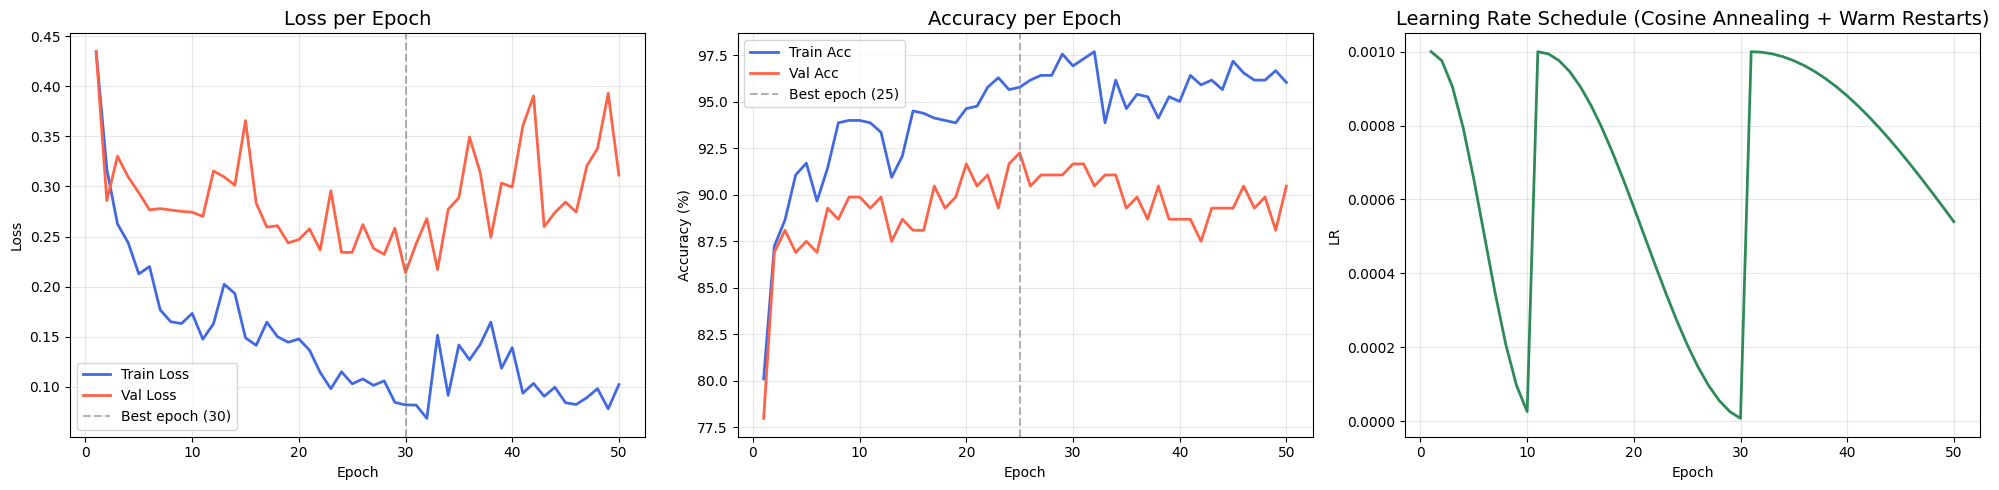

Curve saved → /content/outputs/training_validation_curves.png


In [33]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Loss curve ───────────────────────────────────────────────────────
axes[0].plot(epochs_range, logs['train_loss'], label='Train Loss', color='royalblue',  linewidth=2)
axes[0].plot(epochs_range, logs['val_loss'],   label='Val Loss',   color='tomato',     linewidth=2)
best_ep = logs['val_loss'].index(min(logs['val_loss'])) + 1
axes[0].axvline(best_ep, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_ep})')
axes[0].set_title('Loss per Epoch', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy curve ───────────────────────────────────────────────────
axes[1].plot(epochs_range, [a*100 for a in logs['train_acc']], label='Train Acc', color='royalblue', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in logs['val_acc']],   label='Val Acc',   color='tomato',    linewidth=2)
best_ep_acc = logs['val_acc'].index(max(logs['val_acc'])) + 1
axes[1].axvline(best_ep_acc, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_ep_acc})')
axes[1].set_title('Accuracy per Epoch', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Learning rate schedule ───────────────────────────────────────────
axes[2].plot(epochs_range, logs['lr'], color='seagreen', linewidth=2)
axes[2].set_title('Learning Rate Schedule (Cosine Annealing + Warm Restarts)', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(alpha=0.3)

plt.tight_layout()
curve_path = f'{OUTPUT_DIR}/training_validation_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Curve saved → {curve_path}')

In [34]:
# Also save logs as CSV
logs_df = pd.DataFrame({
    'epoch'     : list(epochs_range),
    'train_loss': logs['train_loss'],
    'train_acc' : [a*100 for a in logs['train_acc']],
    'val_loss'  : logs['val_loss'],
    'val_acc'   : [a*100 for a in logs['val_acc']],
    'lr'        : logs['lr']
})
csv_path = f'{OUTPUT_DIR}/training_logs.csv'
logs_df.to_csv(csv_path, index=False)
print(f'Training logs saved → {csv_path}')
logs_df.tail(10)

Training logs saved → /content/outputs/training_logs.csv


,epoch,train_loss,train_acc,val_loss,val_acc,lr
40,41,0.093783,96.428571,0.360536,88.690476,0.000854
41,42,0.103569,95.918367,0.390354,87.500000,0.000825
42,43,0.090639,96.173469,0.259902,89.285714,0.000794
43,44,0.099696,95.663265,0.273908,89.285714,0.000761
44,45,0.084284,97.193878,0.284459,89.285714,0.000727
45,46,0.082491,96.556122,0.274566,90.476190,0.000692
46,47,0.089304,96.173469,0.320547,89.285714,0.000655
47,48,0.098299,96.173469,0.337968,89.880952,0.000617
48,49,0.078215,96.683673,0.392968,88.095238,0.000579
49,50,0.102347,96.045918,0.311357,90.476190,0.000540


In [35]:
# Load the best checkpoint
model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/best_resnet50.pth', map_location=device))
model.eval()

y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(device), labels.to(device)
        outputs  = model(images)
        probs    = F.softmax(outputs, dim=1)  # explicit Softmax for probabilities
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

test_acc = accuracy_score(y_true, y_pred)
print(f'\n✅  Test Accuracy: {test_acc*100:.2f}%')

Testing:   0%|          | 0/6 [00:00<?, ?it/s]


✅  Test Accuracy: 89.88%


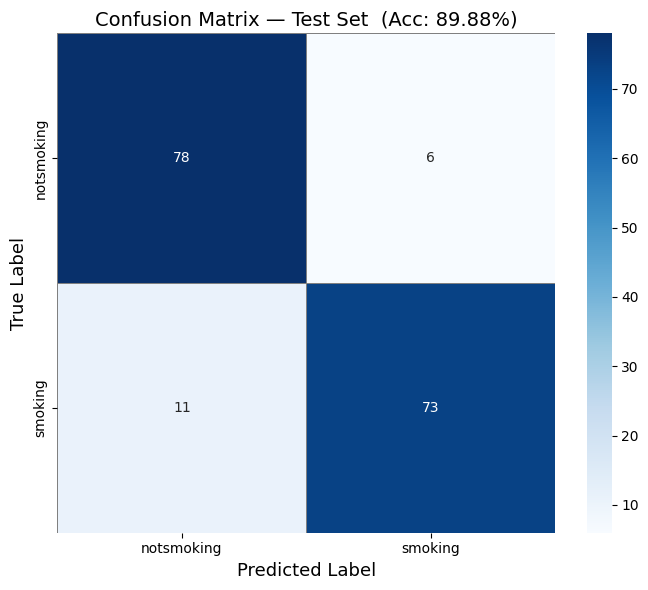

Confusion matrix saved → /content/outputs/confusion_matrix.png


In [36]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_LIST, yticklabels=LABEL_LIST,
    linewidths=0.5, linecolor='gray',
    ax=ax, cbar=True
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label',      fontsize=13)
ax.set_title(f'Confusion Matrix — Test Set  (Acc: {test_acc*100:.2f}%)', fontsize=14)
plt.tight_layout()
cm_path = f'{OUTPUT_DIR}/confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved → {cm_path}')

In [37]:
report = classification_report(y_true, y_pred, target_names=LABEL_LIST, digits=4)
print('=' * 55)
print('         CLASSIFICATION REPORT — TEST SET')
print('=' * 55)
print(report)

# Save report to text file
report_path = f'{OUTPUT_DIR}/classification_report.txt'
with open(report_path, 'w') as f:
    f.write(report)
print(f'Report saved → {report_path}')

         CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

  notsmoking     0.8764    0.9286    0.9017        84
     smoking     0.9241    0.8690    0.8957        84

    accuracy                         0.8988       168
   macro avg     0.9002    0.8988    0.8987       168
weighted avg     0.9002    0.8988    0.8987       168

Report saved → /content/outputs/classification_report.txt


In [38]:
# ── Final Summary ────────────────────────────────────────────────────
print('\n' + '='*55)
print('            FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Model           : ResNet50 (ImageNet pretrained)')
print(f'  Fine-tuned head : Linear(2048→512) → BN → ReLU → Dropout → Linear(512→{NUM_CLASSES})')
print(f'  Split           : 70% train | 15% val | 15% test')
print(f'  Epochs          : {EPOCHS}')
print(f'  Best Val Acc    : {best_val_acc*100:.2f}%  (epoch {best_ep_acc})')
print(f'  Test  Accuracy  : {test_acc*100:.2f}%')
print('='*55)
print(f'\nOutputs saved in: {OUTPUT_DIR}')
print(f'  training_validation_curves.png')
print(f'  confusion_matrix.png')
print(f'  training_logs.csv')
print(f'  classification_report.txt')
print(f'Checkpoint: {CHECKPOINT_DIR}/best_resnet50.pth')


            FINAL RESULTS SUMMARY
  Model           : ResNet50 (ImageNet pretrained)
  Fine-tuned head : Linear(2048→512) → BN → ReLU → Dropout → Linear(512→2)
  Split           : 70% train | 15% val | 15% test
  Epochs          : 50
  Best Val Acc    : 92.26%  (epoch 25)
  Test  Accuracy  : 89.88%

Outputs saved in: /content/outputs
  training_validation_curves.png
  confusion_matrix.png
  training_logs.csv
  classification_report.txt
Checkpoint: /content/checkpoints/best_resnet50.pth
